# Example Lab

Explore `measure_throughput` with a fixed message pane and a live dashboard.
Run cells individually: setup, optional dark measurements and manual work, then the throughput section.
The saved outputs and exploratory plots are historical lab observations, not current hardware status.

Use the workspace `.venv` kernel in JupyterLab. The dashboard uses `ipympl`
(`%matplotlib widget`), `ipywidgets`, and Matplotlib's normal toolbar and animation.
After installing ipympl, reload the JupyterLab page if the widget frontend is missing.

**All Done?** below stops the measurement, sends `stop=True` to each laser in
`LASERS`, and saves the collected samples. Laser stop applies the configured
TEC-off policy. Pausing or closing a display does not stop acquisition.


In [1]:
from pathlib import Path
from dataclasses import asdict
from datetime import datetime, timezone
import math
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import display

TOOLS = next(p.resolve() for p in (Path.cwd(), Path.cwd() / 'tools', Path.cwd() / 'hispec-tib/tools') if (p / 'hispec_fibpcb.py').is_file())
if str(TOOLS) not in sys.path:
    sys.path.insert(0, str(TOOLS))
import hispec_fibpcb as hspcb

plt.rcParams.update({'axes.grid': True, 'grid.alpha': 0.18, 'figure.figsize': (11, 5)})

In [2]:
CHANNEL = 'yj'                         # Change to 'hk' for the other channel.
LASERS = {'yj': ['1028y', '1270j', '1430yj'], 'hk': ['1430hk', '1510h', '2330k']}[CHANNEL]
BROKER, DEVICE = 'hispec.caltech.edu', 'hsfib-tib'

OUTPUT =  f'{CHANNEL}_ao' # _ao or _fei

FIBER = 'M'    # (or S) Match the physical patch before each experiment.

DATA_DIR = TOOLS / 'example_data'


In [3]:
# Physical patch notes for this session; update when moving fibers.
PATCH_NOTES = 'C FEI->5dB->FFLC MM Green (C); B AO->3dB->FFLC MM Yellow(B)'

def setup_snapshot(client, laser):
    """Read experiment context; these queries do not request laser emission."""
    return dict(utc=datetime.now(timezone.utc).isoformat(), setup=PATCH_NOTES,
        status=client.status(), coeff=client.atten_coeff(laser), atten=client.atten(laser),
        laser_status=client.laser(laser), laser_settings=client.laser_settings(laser),
        pd_settings=client.pd_settings(CHANNEL), dark=client.pd_dark(CHANNEL))

def table_records(frame):
    """Keep numeric dtypes; encode text and stream flag tuples as Unicode for allow_pickle=False."""
    if not len(frame.columns):
        return np.empty(len(frame), dtype=[])
    frame = frame.copy()
    string_types = {}
    for name in frame:
        if frame[name].dtype.kind == 'O' or isinstance(frame[name].dtype, pd.StringDtype):
            frame[name] = frame[name].map(lambda v: '|'.join(v) if isinstance(v, tuple) else '' if v is None else str(v))
            string_types[name] = f'U{max(1, frame[name].str.len().max() if len(frame) else 1)}'
    return frame.to_records(index=False, column_dtypes=string_types)

def save_tables(stem, **tables):
    """Archive raw acquisition before analysis. Exclusive creation never overwrites a capture."""
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    stamp = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S_%fZ')
    path = DATA_DIR / f'{stem}_{stamp}.npz'
    arrays = {name: table_records(value) if isinstance(value, pd.DataFrame) else np.asarray(value)
              for name, value in tables.items()}
    if any(a.dtype.hasobject for a in arrays.values()):
        raise TypeError('NPZ tables must have scalar numeric/Unicode columns, not Python objects.')
    with path.open('xb') as file:
        np.savez_compressed(file, **arrays)
    print(path)
    return path


# Connect

In [4]:
if 'pcb' not in globals():
    pcb = hspcb.HispecFibPcb(BROKER, device=DEVICE, connect=True)


## Capture and show status messages from the TIB

In [5]:
import asyncio
import logging
from collections import deque
import ipywidgets as widgets
from IPython.display import display
from html import escape

# Rerunning replaces only this pane and restores the prior client logger first.
if "message_task" in globals():
    message_task.cancel()
if "message_handler" in globals():
    message_client.logger = previous_logger
    message_logger.removeHandler(message_handler)
    message_handler.close()
    message_output.close()

class MessagePaneHandler(logging.Handler):
    """Buffer logs on the MQTT thread; widget updates belong to the kernel loop."""
    def __init__(self):
        super().__init__()
        self.lines = deque(maxlen=500)
        self.dirty = False

    def emit(self, record):
        # logging.Handler.handle holds this handler's lock during emit.
        try:
            self.lines.append(self.format(record) + "\n")
            self.dirty = True
        except Exception:
            self.handleError(record)

async def refresh_message_pane(handler, output):
    """Batch only changed log content at 2 Hz, independently of the plot timer."""
    while True:
        await asyncio.sleep(0.5)
        handler.acquire()
        try:
            if not handler.dirty:
                continue
            text = "".join(handler.lines)
            handler.dirty = False
        finally:
            handler.release()
        # output.outputs = ({"output_type": "stream", "name": "stdout", "text": text},)
        output.value = ('<pre style="margin:0; white-space:pre;">'
                        f'{escape(text)}'
                        '</pre>')


message_client = pcb
previous_logger = pcb.logger
message_logger = logging.Logger(f"throughput.lab.{pcb.device}", level=logging.DEBUG)
message_logger.propagate = False
# message_output = widgets.Output(layout={"height": "260px", "overflow": "auto",
#                                         "border": "1px solid #999"})

message_output = widgets.HTML(
    layout={
        "height": "260px",
        "overflow": "auto",
        "border": "1px solid #999",
        "display": "block",
    }
)
message_handler = MessagePaneHandler()
message_handler.setFormatter(logging.Formatter("%(asctime)s %(levelname)s %(message)s"))
message_logger.addHandler(message_handler)
pcb.logger = message_logger
message_task = asyncio.create_task(refresh_message_pane(message_handler, message_output))
display(message_output)

HTML(value='', layout=Layout(border_bottom='1px solid #999', border_left='1px solid #999', border_right='1px s…

# Status

In [51]:
laser_name = '1028y'
live_context = setup_snapshot(pcb, laser_name)
display(live_context)

{'utc': '2026-09-23T18:51:49.454109+00:00',
 'setup': 'C FEI->5dB->FFLC MM Green (C); B AO->3dB->FFLC MM Yellow(B)',
 'status': Status(
   fw='e2c0afc9e388-dirty',
   boots=76,
   board='tib',
   board_ok=True,
   mems_switches=8,
   relay_err=0,
   amb_c=20.25,
   pd_on_s=1977,
   laserbank_on_s=70239,
   lastcmd=LastCommand(name='measure_throughput', src='mqtt', t_ms=68592241),
   ip=None,
   lasers=(),
   attens=()
 ),
 'coeff': AttenuatorCoeff(
   dac1=AttenuatorPhysicalCoeff(
   fvoa_50pct_mv=3329.83,
   slope_inv_fvoa_mv=0.00317173,
   max_atten_db=71.1299,
   max_calibrated_db=55,
   gain=1.533,
   correction_coeff=(-12.0707, -11.9753, -17.1866, -2.57022, -3.82301, -1.04058),
   rms_db=0.121127
 ),
   dac2=AttenuatorPhysicalCoeff(
   fvoa_50pct_mv=2988.49,
   slope_inv_fvoa_mv=0.00222533,
   max_atten_db=68.1514,
   max_calibrated_db=55,
   gain=1.533,
   correction_coeff=(-9.98369, -28.3383, -14.5658, -17.6808, -3.13973, -4.10104),
   rms_db=0.213519
 )
 ),
 'atten': Attenuator

## Dark

Take repeated dark measurements with the one-liners below. Each uses a fixed
wait; `pending=True` means the displayed dark is still the previous result.
The acceptance cell starts a new capture with persistence enabled.


In [52]:
RUN_DARK = True
DARK_DURATION_MS = 2000
if RUN_DARK:
    pcb.stop_throughput('all')
    for name in LASERS:
        pcb.laser(name, stop=True)
        pcb.atten(name, value1_mv=3000, value2_mv=3000)

    pcb.pd_dark(CHANNEL, duration_ms=DARK_DURATION_MS, persist=False);time.sleep(2.1);x=pcb.pd_dark(CHANNEL);print(f'{CHANNEL} Dark: {x.dark.mean_mv:.3f}±{x.dark.mean_net_err_mv:.3f} (pending={x.pending})')
    pcb.pd_dark(CHANNEL, duration_ms=DARK_DURATION_MS, persist=False);time.sleep(2.1);x=pcb.pd_dark(CHANNEL);print(f'{CHANNEL} Dark: {x.dark.mean_mv:.3f}±{x.dark.mean_net_err_mv:.3f} (pending={x.pending})')
    pcb.pd_dark(CHANNEL, duration_ms=DARK_DURATION_MS, persist=False);time.sleep(2.1);x=pcb.pd_dark(CHANNEL);print(f'{CHANNEL} Dark: {x.dark.mean_mv:.3f}±{x.dark.mean_net_err_mv:.3f} (pending={x.pending})')
    pcb.pd_dark(CHANNEL, duration_ms=DARK_DURATION_MS, persist=False);time.sleep(2.1);x=pcb.pd_dark(CHANNEL);print(f'{CHANNEL} Dark: {x.dark.mean_mv:.3f}±{x.dark.mean_net_err_mv:.3f} (pending={x.pending})')
    pcb.pd_dark(CHANNEL, duration_ms=DARK_DURATION_MS, persist=False);time.sleep(2.1);x=pcb.pd_dark(CHANNEL);print(f'{CHANNEL} Dark: {x.dark.mean_mv:.3f}±{x.dark.mean_net_err_mv:.3f} (pending={x.pending})')
    pcb.pd_dark(CHANNEL, duration_ms=DARK_DURATION_MS, persist=False);time.sleep(2.1);x=pcb.pd_dark(CHANNEL);print(f'{CHANNEL} Dark: {x.dark.mean_mv:.3f}±{x.dark.mean_net_err_mv:.3f} (pending={x.pending})')

yj Dark: -1.192±0.044 (pending=False)
yj Dark: -1.156±0.045 (pending=False)
yj Dark: -1.109±0.054 (pending=False)
yj Dark: -1.055±0.065 (pending=False)
yj Dark: -1.136±0.058 (pending=False)
yj Dark: -1.150±0.051 (pending=False)


In [53]:
ACCEPT_DARK = False                    
if ACCEPT_DARK and RUN_DARK:
    pcb.pd_dark(CHANNEL, duration_ms=DARK_DURATION_MS, reset_lowest=False, persist=True)
    time.sleep(DARK_DURATION_MS / 1000 + .1)
    accepted_dark = pcb.pd_dark(CHANNEL)
    print(f'pending={accepted_dark.pending}')
    display(pd.DataFrame([asdict(accepted_dark.dark), asdict(accepted_dark.lowest_dark)], index=['active dark readback', 'lowest dark']))

# Set a route

In [56]:
#Show the active routes
pcb.mems_route().active_routes #routes and current config

(NamedValue(name='yj_ao', value=('yj_1430', 'yj_laser')),
 NamedValue(name='yj_fei', value=('no source',)),
 NamedValue(name='yj_pd', value=('yj_mm',)),
 NamedValue(name='hk_ao', value=('hk_1430', 'hk_laser')),
 NamedValue(name='hk_fei', value=('no source',)),
 NamedValue(name='hk_pd', value=('hk_mm',)))

In [22]:
#set an individual switch
pcb.mems_switch('hk_forward_retro', state='A', force=True)

MemsSwitchDetail(
  name='hk_forward_retro',
  state='A',
  duty_cycle=1,
  cycle_ms=0,
  a_ms=0,
  b_ms=0,
  stop_in_s=0
)

In [57]:
pcb.mems_route('yj_laser','yj_ao'), pcb.mems_route('yj_mm', 'yj_pd')
for r in pcb.mems_route().active_routes:
    if r.name.startswith(CHANNEL):
        print(f'{", ".join(r.value)} ->  {r.name}')
print('\nIndividual switch settings:')
pcb.mems()

yj_1430, yj_laser ->  yj_ao
no source ->  yj_fei
yj_mm ->  yj_pd

Individual switch settings:


(MemsSwitchState(name='yj_forward_retro', state='A', duty_cycle=1),
 MemsSwitchState(name='yj_laser_cal', state='A', duty_cycle=1),
 MemsSwitchState(name='yj_ao_fei', state='A', duty_cycle=1),
 MemsSwitchState(name='hk_forward_retro', state='A', duty_cycle=1),
 MemsSwitchState(name='hk_laser_cal', state='A', duty_cycle=1),
 MemsSwitchState(name='hk_ao_fei', state='A', duty_cycle=1),
 MemsSwitchState(name='yj_mm_sm', state='A', duty_cycle=1),
 MemsSwitchState(name='hk_mm_sm', state='A', duty_cycle=1))

# Stop emission

In [58]:
for laser_name in LASERS:
    pcb.laser(laser_name, value=0)  # Zero emission retains readiness; stop=True applies the TEC-off policy.

# Set an attenuation and laser level

In [59]:
laser_name = '1028y'

pcb.atten(laser_name, value_db=40)
print(pcb.atten(laser_name))

pcb.atten(laser_name, value1_db=40, value2_db=0)
print(pcb.atten(laser_name))

time.sleep(.15)


pcb.laser(laser_name, value=.01, autooff_s=600)
print(pcb.laser(laser_name))

print(pcb.pd(CHANNEL))

pcb.laser(laser_name, value=0)




AttenuatorState(
  db=40.0106,
  linear=9.97572e-05,
  v1_mv=2503.2,
  v2_mv=2437.94,
  db1=19.9942,
  db2=20.0163,
  linear1=0.0100133,
  linear2=0.00996252
)
AttenuatorState(
  db=39.9846,
  linear=0.000100355,
  v1_mv=2712.67,
  v2_mv=0,
  db1=39.9846,
  db2=0,
  linear1=0.000100355,
  linear2=1
)


PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=42.521 threshold_mv=10.000 uptime_ms=70313080


LaserStatus(
  name='1028y',
  powered=True,
  ready=True,
  blocked_reason=None,
  tec_on_s=3350,
  emit_on_s=0,
  emit_total_s=18966,
  temp_c=24.96,
  i_mA=16.9,
  value=0.0102,
  power_mw=0.446,
  nominal_nm=1028.01,
  tuned_nm=1024.51,
  tune_nm=0,
  tec_ma=0,
  diode_v=1.3,
  tec_v=0,
  off_in_s=600,
  oc_fault=False
)
PhotodiodeValues(
  yj=PhotodiodeChannelValues(
  raw=5758,
  mv=359.875,
  net_mv=361.025,
  net_err_mv=0.326288,
  power_uw=1.94099e-05,
  power_err_uw=1.75424e-08,
  dark_mv=-1.15,
  dark_err_mv=0.0509576,
  window=PhotodiodeWindow(
  duration_ms=500,
  failed_samples=0,
  mean_mv=356.494,
  mean_net_mv=357.644,
  rms_mv=2.64951,
  mean_net_err_mv=0.839396,
  min_mv=350.875,
  max_mv=360.25,
  power_uw=1.92282e-05,
  power_err_uw=4.51288e-08
),
  pd_powered=True,
  pd_on_s=2050
),
  hk=None
)


CommandOk(status='ok')

# Monitor the signal


For passive external light (including starlight), use:
```python
monitor = pcb.measure_throughput("none", channel=CHANNEL, fiber=FIBER,
                                 autolevel=False, collect=True)
```
This selects the MM/SM return and corrects detected power/error, leaving launch
switches untouched. To route external calibration light too, supply both
`input="yj_cal"` and `output="yj_ao"` (or the corresponding HK labels).
The command prepares ownership before applying the independent launch and return
routes. Unknown emission means source power and throughput remain NaN; PD power,
its error, and detector S/N remain useful. Return defaults are 0.98 MM / 0.60 SM;
per-laser overrides are used only with a known laser. Stop with `monitor.stop()`.


### Live dashboard (display controls only)

Pan/zoom with the toolbar; **Follow data** restores autoscaling. Pause freezes
only the plot. Closing the figure stops its timer. Collection and hardware
continue. Rerunning the dashboard cell restarts collection and replaces the display.

The full-width throughput panel shows the power ratio and reported ± total
error. Its right axis shows path loss, `-10 log10(tp)`, in dB. Below it:

- **PD input:** individual net reading ± error, with the 400–1600 mV
  net control band and the raw-input ceiling translated using startup dark.
- **S/N:** individual PD reading/error and throughput/total error. Calibration
  uncertainty can limit total S/N even with excellent detector S/N. Autolevel
  uses the voltage band, not an S/N threshold.
- **Source and attenuation:** drive current and combined dynamic attenuation.
- **Estimated laser optical output:** µW before dynamic and static attenuation,
  inferred from current calibration; this is not an optical power measurement.
- **Route-corrected optical power:** delivered and detected nW ± error. Delivered
  power includes outbound static loss and dynamic attenuation; detected power
  is divided by the return-path transmission.

Overrange (raw input ≥2000 mV) marks the throughput as a **nominal lower bound**
and path loss as an upper bound. PD/throughput errors and S/N are undefined there.
Nonpositive log values and missing acquisitions appear as gaps. Collection/NPZ
preserve signed net voltages, zero-clipped power, errors, flags, and timestamps. Only the
visible record tail is converted per frame; refresh is capped at 4 Hz.

For passive light, the source and throughput panels have no defined values;
the PD input, detected nW, and detector S/N remain available.


In [38]:
pcb.measure_throughput?

Signature:
pcb.measure_throughput(
    laser: 'str',
    *,
    fiber: "Literal['M', 'S']" = 'M',
    autolevel: 'bool' = True,
    initial_level: 'float | None' = None,
    input: 'str | None' = None,
    output: 'str | None' = None,
    max_flux_ph_s: 'float | None' = None,
    off_in_s: 'int' = 300,
    format: "Literal['json', 'binary']" = 'binary',
    collect: 'bool' = False,
    channel: "Literal['yj', 'hk'] | None" = None,
    max_samples: 'int' = 20000,
) -> 'CommandOk | ThroughputMonitor'
Docstring:
Start a measurement, using binary telemetry unless JSON is requested.

Applies launch and MM/SM return routes and captures their losses for the run.
For laser="none", specify channel and autolevel=False: only the return is
selected unless both input and output are supplied. Detected power is
return-corrected; source power and throughput are unknown (NaN).
With collect=True, return a collector whose stop() stops this channel's
measurement and any laser used by its autolevel operati

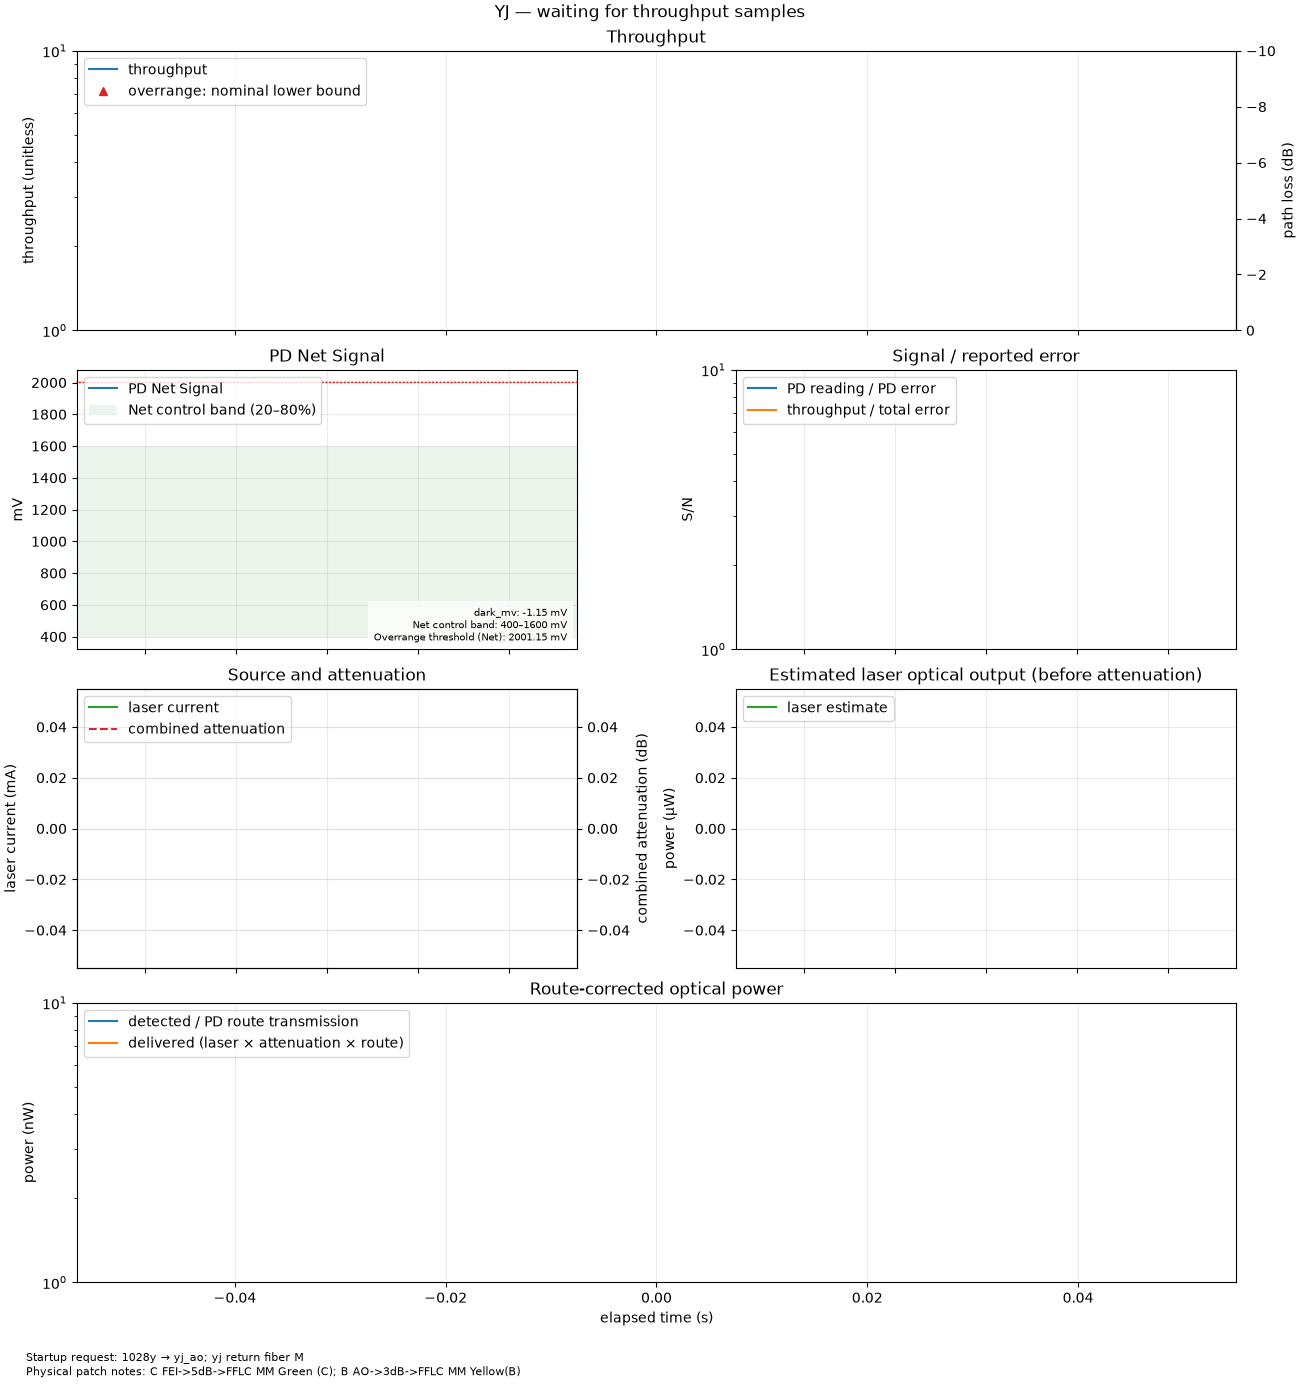

In [8]:
%matplotlib widget

# Live exploration uses the widget backend; run the save/stop cell when finished.
START_LIVE_DASHBOARD = True
LIVE_LASER, LIVE_CAPACITY_SECONDS = LASERS[0], 600.
if START_LIVE_DASHBOARD:
    # Dispose of this dashboard's previous display and collector before restarting.
    if 'tp_animation' in globals() and tp_animation.event_source is not None:
        tp_animation.pause()
    if 'tp_figure' in globals():
        plt.close(tp_figure)
    if 'live_monitor' in globals():
        live_monitor.stop()

    if not np.isfinite(LIVE_CAPACITY_SECONDS) or LIVE_CAPACITY_SECONDS <= 0:
        raise ValueError('Choose a positive collector capacity duration.')
    # Stop an earlier owner before starting: an autolevel owner may shut off its laser.
    # This manual collector does not start the laser; stopping it leaves manual emission alone.
    pcb.stop_throughput(CHANNEL)
    live_monitor = pcb.measure_throughput(
        LIVE_LASER, channel=CHANNEL, fiber=FIBER,
        output=OUTPUT if LIVE_LASER != 'none' else None, autolevel=False,
        off_in_s=0, collect=True, format='binary',
        max_samples=max(1000, math.ceil(LIVE_CAPACITY_SECONDS / .05 * 1.5) + 1000))

    try:
        with plt.ioff():
            tp_figure, tp_animation = live_monitor.plot_live(channel=CHANNEL, max_points=600)
            pd_axis = tp_figure.axes[1]
            pd_axis.set(title='PD Net Signal', ylabel='mV')
            for artist in [*pd_axis.lines, *pd_axis.patches]:
                if artist.get_label() in ('raw input ceiling', 'net control band (20-80%)'):
                    artist.remove()
                elif artist.get_label() == 'net reading':
                    artist.set_label('PD Net Signal')
            live_dark_mv = pcb.pd_dark(CHANNEL).dark.mean_mv
            net_ceiling_mv = hspcb.PD_ADC_USABLE_MV-live_dark_mv
            low_mv, high_mv = .2*hspcb.PD_ADC_USABLE_MV, .8*hspcb.PD_ADC_USABLE_MV
            # These reference artists do not contribute to relim(): the Net data/error bands set the limits.
            # The control band already uses Net coordinates; the ADC ceiling must use the captured dark_mv.
            control_band = Rectangle((0, 0), 1, 0, transform=pd_axis.transAxes, facecolor='green', alpha=.08,
                                     label='Net control band (20–80%)')
            pd_axis.add_artist(control_band)
            if np.isfinite(net_ceiling_mv):
                pd_axis.annotate('', xy=(0, net_ceiling_mv), xytext=(1, net_ceiling_mv),
                    xycoords=pd_axis.get_yaxis_transform(), annotation_clip=True,
                    arrowprops=dict(arrowstyle='-', color='C3', linestyle=':', shrinkA=0, shrinkB=0))
            guide_text = ((f'dark_mv: {live_dark_mv:g} mV\n' if np.isfinite(live_dark_mv) else 'dark_mv: unrecorded\n')
                          + f'Net control band: {low_mv:g}–{high_mv:g} mV\n'
                          + (f'Overrange threshold (Net): {net_ceiling_mv:g} mV' if np.isfinite(net_ceiling_mv)
                             else 'Overrange threshold (Net): dark_mv unrecorded'))
            pd_axis.text(.98, .02, guide_text, transform=pd_axis.transAxes, ha='right', va='bottom', fontsize=7,
                         bbox=dict(facecolor='white', alpha=.8, edgecolor='none'))

            def place_control_band(axis, band=control_band, lower=low_mv, upper=high_mv):
                """Follow Net-axis zoom/animation without contributing reference values to autoscaling."""
                bottom, top = axis.get_ylim()
                band.set_y((lower-bottom)/(top-bottom))
                band.set_height((upper-lower)/(top-bottom))

            pd_axis.callbacks.connect('ylim_changed', place_control_band)
            pd_axis.relim()
            pd_axis.autoscale_view()
            place_control_band(pd_axis)
            pd_axis.legend(loc='upper left')
            # The driver's animated suptitle changes each frame; keep the route caption in a separate footer.
            tp_figure.set_size_inches(13, 14)
            tp_figure.get_layout_engine().set(rect=(0, .05, 1, .95))
            tp_figure.text(.02, .015,
                f'Startup request: {LIVE_LASER} → {OUTPUT if LIVE_LASER != "none" else "launch unchanged"}; '
                f'{CHANNEL} return fiber {FIBER}\nPhysical patch notes: {PATCH_NOTES}',
                ha='left', va='bottom', fontsize=8)
        display(tp_figure.canvas)
        tp_figure.canvas.draw()
    except BaseException:
        live_monitor.stop()
        raise
# tp_animation.pause()/resume() affect only display. Hardware and collection keep running.

## Play with settings and watch the data

In [11]:
pcb.laser('1028y', value=.01)

CommandOk(status='ok')

In [10]:
pcb.atten('1028y', value_db=35)
time.sleep(1)
pcb.atten('1028y', value_db=45)

AttenuatorState(
  db=45.0008,
  linear=3.16173e-05,
  v1_mv=2665.14,
  v2_mv=2224.44,
  db1=34.9592,
  db2=10.0415,
  linear1=0.000319211,
  linear2=0.0990482
)

## Access the data

In [18]:
print('Record names:\n    - '+'\n    - '.join(live_monitor.to_recarray().dtype.names))
live_monitor.to_recarray()['pd_net_mv'][-100:].std()

Record names:
    - channel
    - laser
    - autolevel
    - t_ms
    - tp
    - tp_err
    - tp_pd_err
    - pd_power_nw
    - pd_power_err_nw
    - delivered_power_nw
    - delivered_power_err_nw
    - laser_output_power_uw
    - laser_output_power_err_uw
    - pd_route_tx
    - laser_route_tx
    - atten_tx
    - pd_mv
    - pd_net_mv
    - pd_net_err_mv
    - laser_current_ma
    - atten_db
    - wavelength_nm
    - pd_raw
    - pd_ontime_s
    - laser_current_ontime_s
    - flags


np.float64(8.7229240904355)

# All Done?

In [19]:
SAVE_AND_STOP_LIVE = True
if SAVE_AND_STOP_LIVE:
    try:
        try:
            live_monitor.stop()
        finally:
            # Manual emission is independent of this collector; attempt every channel laser.
            for laser_name in LASERS:
                try:
                    pcb.laser(laser_name, stop=True)
                except Exception as exc:
                    print(f'Laser stop failed for {laser_name}: {exc}')
    finally:
        try:
            path = save_tables('throughput_live', samples=live_monitor.to_dataframe())
        finally:
            plt.close(tp_figure)
            %matplotlib inline


/Users/jibailey/src/hispec-zephyr-mlang/hispec-tib/tools/example_data/throughput_live_20260923T191702_138780Z.npz


In [20]:
# Standalone laser stop for manual experiments or a retry after a reported failure.
for laser_name in LASERS:
    pcb.laser(laser_name, stop=True)


In [21]:
# Optional display/log cleanup
if "message_task" in globals():
    message_task.cancel()
    del message_task
if "message_handler" in globals():
    message_client.logger = previous_logger
    message_logger.removeHandler(message_handler)
    message_handler.close()
    message_output.close()
    del message_handler
